# Predizione dei valori di mercato di giocatori nei top 5 campionati europei

In [132]:
import torch

In [133]:
# Verifica disponibilità GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device in uso: {device}")

x = torch.randn(1024, 1024, device=device)
y = x @ x.T # test di prodotto tra matrici sulla gpu. per verificare la compatibilità della gpu.
print("OK, y shape:", y.shape, "on", device)

Device in uso: cpu
OK, y shape: torch.Size([1024, 1024]) on cpu


## 1. Preparazione dei dati

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv
from src.Resource import stampa_colonne

In [135]:
stampa_colonne('data/players.csv')

Colonne di 'data/players.csv' (26 totali):
  0: player_id
  1: first_name
  2: last_name
  3: name
  4: last_season
  5: current_club_id
  6: player_code
  7: country_of_birth
  8: city_of_birth
  9: country_of_citizenship
  10: date_of_birth
  11: sub_position
  12: position
  13: foot
  14: height_in_cm
  15: contract_expiration_date
  16: agent_name
  17: image_url
  18: international_caps
  19: international_goals
  20: current_national_team_id
  21: url
  22: current_club_domestic_competition_id
  23: current_club_name
  24: market_value_in_eur
  25: highest_market_value_in_eur


In [136]:
stampa_colonne('data/appearances.csv')

Colonne di 'data/appearances.csv' (13 totali):
  0: appearance_id
  1: game_id
  2: player_id
  3: player_club_id
  4: player_current_club_id
  5: date
  6: player_name
  7: competition_id
  8: yellow_cards
  9: red_cards
  10: goals
  11: assists
  12: minutes_played


In [137]:
stampa_colonne('data//player_valuations.csv')

Colonne di 'data//player_valuations.csv' (6 totali):
  0: player_id
  1: date
  2: market_value_in_eur
  3: current_club_name
  4: current_club_id
  5: player_club_domestic_competition_id


### 1.1 Pulizia dei dati e creazione dataset corretto

In [138]:
# Caricamento dati
df_players = pd.read_csv('data/players.csv')
df_appearances = pd.read_csv('data/appearances.csv')
df_valuations = pd.read_csv('data/player_valuations.csv')

# Conversione delle date in formato datetime
df_valuations['date'] = pd.to_datetime(df_valuations['date'])
df_appearances['date'] = pd.to_datetime(df_appearances['date'])
df_players['date_of_birth'] = pd.to_datetime(df_players['date_of_birth'], errors='coerce')

# Filtro dei top 5 campionati
top_5_leagues = ['GB1', 'ES1', 'IT1', 'L1', 'FR1']
df_players = df_players[df_players['current_club_domestic_competition_id'].isin(top_5_leagues)].copy()

# Estrazione dell'ultima valutazione per ogni giocatore
df_valuations_latest = (
    df_valuations.sort_values('date')
    .groupby('player_id')
    .tail(1)
    .rename(columns={'date': 'valuation_date'})
)

# Unione delle valutazioni ai rispettivi giocatori 
df_players = df_players.drop(columns=['market_value_in_eur']) # Rimozione del prezzo da df_players per evitare il conflitto di nomi 
df = pd.merge(df_players, df_valuations_latest[['player_id', 'valuation_date', 'market_value_in_eur']],
              on='player_id', how='inner')

app_merged = pd.merge(df_appearances, df[['player_id', 'valuation_date']], on='player_id', how='inner') # Incrocio delle presenze con le date di valutazione

# Controllo temporale della valutazione
app_valid = app_merged[app_merged['date'] <= app_merged['valuation_date']]

# Aggregazione delle statistiche
stats = app_valid.groupby('player_id').agg(
    appearances_count=('appearance_id', 'count'),
    minutes_played=('minutes_played', 'sum'),
    goals=('goals', 'sum'),
    assists=('assists', 'sum')
).reset_index()

# Unione delle statistiche al dataframe principale
df = pd.merge(df, stats, on='player_id', how='left')
df[['appearances_count', 'minutes_played', 'goals', 'assists']] = df[['appearances_count', 'minutes_played', 'goals', 'assists']].fillna(0)

# Feature normalizzate per minuti giocati
min_minuti_soglia = 270  # Limite di minutaggio equivalente a 3 partite intere
df['goals_per_90'] = np.where(
    df['minutes_played'] >= min_minuti_soglia,
    (df['goals'] / df['minutes_played']) * 90,
    0  # sotto soglia, consideriamo il dato inaffidabile
)
df['assists_per_90'] = np.where(
    df['minutes_played'] >= min_minuti_soglia,
    (df['assists'] / df['minutes_played']) * 90,
    0
)

df['has_appearance_data'] = (df['appearances_count'] > 0).astype(int)

# Calcolo dell'età (al momento della valutazione)
df['Age'] = (df['valuation_date'] - df['date_of_birth']).dt.days / 365.25

# Creazione dataframe
features_base = ['Age', 'appearances_count', 'minutes_played', 'goals', 'assists',
                  'goals_per_90', 'assists_per_90', 'has_appearance_data',
                  'position', 'current_club_domestic_competition_id']
label = 'market_value_in_eur'

df_clean = df[['name'] + features_base + [label]].dropna()

print(f"Dataset pronto! Giocatori validi: {len(df_clean)}")
print(df_clean.columns.tolist())
print(df_clean.shape)

Dataset pronto! Giocatori validi: 10694
['name', 'Age', 'appearances_count', 'minutes_played', 'goals', 'assists', 'goals_per_90', 'assists_per_90', 'has_appearance_data', 'position', 'current_club_domestic_competition_id', 'market_value_in_eur']
(10694, 12)


In [139]:
# Codifica delle feature categoriche
df_export = pd.get_dummies(df_clean, columns=['position', 'current_club_domestic_competition_id'], drop_first=True)

# Rimozione dei nomi
df_export = df_export.drop(columns=['name'])

# Conversione delle colonne booleane in interi 0/1
bool_cols = df_export.select_dtypes(include='bool').columns
df_export[bool_cols] = df_export[bool_cols].astype(int)

# Export dei dati
df_export.to_csv('./data/player_data_clean.csv', index=False)
print(f"Esportate {df_export.shape[0]} righe, {df_export.shape[1]} colonne")
print(df_export.columns.tolist())

Esportate 10694 righe, 17 colonne
['Age', 'appearances_count', 'minutes_played', 'goals', 'assists', 'goals_per_90', 'assists_per_90', 'has_appearance_data', 'market_value_in_eur', 'position_Defender', 'position_Goalkeeper', 'position_Midfield', 'position_Missing', 'current_club_domestic_competition_id_FR1', 'current_club_domestic_competition_id_GB1', 'current_club_domestic_competition_id_IT1', 'current_club_domestic_competition_id_L1']


## 2. Caricamento del dataset ripulito

In [140]:
X = []
Y = []

# Import dei dati
df_import = pd.read_csv('./data/player_data_clean.csv')

# Estrazione di X e Y come array Numpy 
X = df_import.drop(columns=['market_value_in_eur']).values
Y = df_import['market_value_in_eur'].values

print(X.shape)
print(Y.shape)

# Trasformazione logaritmica del prezzo
Y = np.log1p(Y / 1_000_000.0)

(10694, 16)
(10694,)


### 2.1 Rimescolamento dei dati

In [141]:
# Seed per la riproducibilità
seed = 123
np.random.seed(seed)
torch.manual_seed(seed)

# Mescolamento dei dati
perm = np.random.permutation(len(X))
X = X[perm]
Y = Y[perm]

### 2.2 Suddivisione dei dati

In [142]:
# 20% Test - 15% Validation - 65% Train
TEST_RATIO = 0.2
VAL_RATIO = 0.15

test_amount = round(len(X) * TEST_RATIO)
val_amount = round(len(X) * VAL_RATIO)
print(f"Test: {test_amount}, Val: {val_amount}, Train: {len(X) - test_amount - val_amount}")

Test: 2139, Val: 1604, Train: 6951


In [143]:
# Conversione in tensori
X_testing = torch.tensor(X[:test_amount]).to(device)
Y_testing = torch.tensor(Y[:test_amount]).to(device).to(torch.float32).view(-1, 1)

X_val = torch.tensor(X[test_amount:test_amount+val_amount]).to(device)
Y_val = torch.tensor(Y[test_amount:test_amount+val_amount]).to(device).to(torch.float32).view(-1, 1)

X_training = torch.tensor(X[test_amount+val_amount:]).to(device)
Y_training = torch.tensor(Y[test_amount+val_amount:]).to(device).to(torch.float32).view(-1, 1)

print(f"Shape Train: {X_training.shape}, Val: {X_val.shape}, Test: {X_testing.shape}")
print(f"Shape target Train: {Y_training.shape}, Val: {Y_val.shape}, Test: {Y_testing.shape}")

Shape Train: torch.Size([6951, 16]), Val: torch.Size([1604, 16]), Test: torch.Size([2139, 16])
Shape target Train: torch.Size([6951, 1]), Val: torch.Size([1604, 1]), Test: torch.Size([2139, 1])


### 2.3 Normalizzazione dei dati

In [144]:
# Calcolo media e deviazione std sui dati di training
X_mean = X_training.mean(0)
X_std = X_training.std(0)

# Normalizzazione
X_training_norm = (X_training - X_mean) / X_std
X_val_norm = (X_val - X_mean) / X_std
X_testing_norm = (X_testing - X_mean) / X_std

# Caricamento sul device individuato
X_training_norm = X_training_norm.to(device)
X_val_norm = X_val_norm.to(device)
X_testing_norm = X_testing_norm.to(device)

## 3. Training

In [145]:
from sklearn.preprocessing import PolynomialFeatures

In [146]:
n_numeric = 7  # Le 7 fature numeriche Age, appearances_count, minutes_played, goals, assists, goals_per_90, assists_per_90

# Conversione in Numpy
X_train_np = X_training_norm.cpu().numpy()
X_test_np = X_testing_norm.cpu().numpy()
X_val_np = X_val_norm.cpu().numpy()

# Divisione tra feature numeriche e categoriche
X_train_numeric = X_train_np[:, :n_numeric]
X_train_categorical = X_train_np[:, n_numeric:]
X_test_numeric = X_test_np[:, :n_numeric]
X_test_categorical = X_test_np[:, n_numeric:]
X_val_numeric = X_val_np[:, :n_numeric]
X_val_categorical = X_val_np[:, n_numeric:]

# Creazione features polinomiali di grado 2 sulle features numeriche
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly_numeric = poly.fit_transform(X_train_numeric)
X_test_poly_numeric = poly.transform(X_test_numeric)
X_val_poly_numeric = poly.transform(X_val_numeric)

# Aggregazione feature polinomiali con categoriche
X_train_poly_full = np.hstack([X_train_poly_numeric, X_train_categorical])
X_test_poly_full = np.hstack([X_test_poly_numeric, X_test_categorical])
X_val_poly_full = np.hstack([X_val_poly_numeric, X_val_categorical])

# Normalizzazione
X_poly_training_norm = torch.tensor(X_train_poly_full, dtype=torch.float32).to(device)
X_poly_testing_norm = torch.tensor(X_test_poly_full, dtype=torch.float32).to(device)
X_poly_val_norm = torch.tensor(X_val_poly_full, dtype=torch.float32).to(device)

print(f"Feature finali: {X_poly_training_norm.shape[1]}")
print(Y_training.shape)

Feature finali: 44
torch.Size([6951, 1])


### 3.1 Modelli Lineari

In [147]:
from src.Resource import LinearRegressor, train_regression_model, stampa_metriche
from torch import nn

In [148]:
lr = 0.0001  
epochs = 4000

# Modello lineare
model = LinearRegressor(X_poly_training_norm.shape[1], 1)
model = model.to(device)

model = train_regression_model(
    model,
    X_poly_training_norm, Y_training.squeeze(),
    X_poly_val_norm,      Y_val.squeeze(),
    exp_name='player_value_linear_regression_ridge',
    criterion=nn.MSELoss(),
    optimizer=None,
    epochs=epochs,
    lr=lr,
    momentum=0.9,
    weight_decay=0.01,
    verbose=True,
    clear_gpu_after=True
)

Epoch [10/4000] 		 loss training: 1.5082 	 loss_val: 1.3910
Epoch [20/4000] 		 loss training: 1.2143 	 loss_val: 1.1269
Epoch [30/4000] 		 loss training: 1.1673 	 loss_val: 1.1049
Epoch [40/4000] 		 loss training: 1.1246 	 loss_val: 1.0771
Epoch [50/4000] 		 loss training: 1.0821 	 loss_val: 1.0388
Epoch [60/4000] 		 loss training: 1.0539 	 loss_val: 1.0140


Epoch [70/4000] 		 loss training: 1.0306 	 loss_val: 0.9938
Epoch [80/4000] 		 loss training: 1.0085 	 loss_val: 0.9749
Epoch [90/4000] 		 loss training: 0.9878 	 loss_val: 0.9564
Epoch [100/4000] 		 loss training: 0.9684 	 loss_val: 0.9384
Epoch [110/4000] 		 loss training: 0.9499 	 loss_val: 0.9207
Epoch [120/4000] 		 loss training: 0.9322 	 loss_val: 0.9036
Epoch [130/4000] 		 loss training: 0.9154 	 loss_val: 0.8872
Epoch [140/4000] 		 loss training: 0.8993 	 loss_val: 0.8715
Epoch [150/4000] 		 loss training: 0.8839 	 loss_val: 0.8565
Epoch [160/4000] 		 loss training: 0.8691 	 loss_val: 0.8422
Epoch [170/4000] 		 loss training: 0.8549 	 loss_val: 0.8284
Epoch [180/4000] 		 loss training: 0.8414 	 loss_val: 0.8152
Epoch [190/4000] 		 loss training: 0.8283 	 loss_val: 0.8025
Epoch [200/4000] 		 loss training: 0.8158 	 loss_val: 0.7903
Epoch [210/4000] 		 loss training: 0.8037 	 loss_val: 0.7786
Epoch [220/4000] 		 loss training: 0.7921 	 loss_val: 0.7673
Epoch [230/4000] 		 loss tr

In [149]:
# Valutazione
model.eval()
with torch.no_grad():
    preds_train = model(X_poly_training_norm).view(-1).cpu()
    preds_val   = model(X_poly_val_norm).view(-1).cpu()
    preds_test  = model(X_poly_testing_norm).view(-1).cpu()

    y_train = Y_training.squeeze().cpu()
    y_val   = Y_val.squeeze().cpu()
    y_test  = Y_testing.squeeze().cpu()

# Metriche logaritmiche
print("Metriche in scala logaritmica:")
stampa_metriche("training", y_train, preds_train)
stampa_metriche("validation", y_val, preds_val)
stampa_metriche("test", y_test, preds_test)

# Metriche in scala reale
preds_test_milioni = np.expm1(preds_test.numpy())
y_test_milioni = np.expm1(y_test.numpy())

print("\nPerformance reali:")
stampa_metriche("test",y_test_milioni,preds_test_milioni)

Metriche in scala logaritmica:
Performance in training:
	MSE: 0.2574 | RMSE: 0.5073 | MAE: 0.3573 | R^2: 0.7202
Performance in validation:
	MSE: 0.2666 | RMSE: 0.5164 | MAE: 0.3596 | R^2: 0.7100
Performance in test:
	MSE: 0.2333 | RMSE: 0.4830 | MAE: 0.3423 | R^2: 0.7432

Performance reali:
Performance in test:
	MSE: 50.9057 | RMSE: 7.1348 | MAE: 2.1026 | R^2: 0.5169


In [150]:
# Stampa 10 peggiori errori
errori = np.abs(y_test_milioni - preds_test_milioni)
peggiori_idx = np.argsort(errori)[-10:][::-1]

print("Reale vs Predetto (Mln €) per i 10 errori più grandi:")
for i in peggiori_idx:
    print(f"  Reale: {y_test_milioni[i]:6.1f} | Predetto: {preds_test_milioni[i]:6.1f} | Errore: {errori[i]:6.1f}")

print(f"\nErrore medio su questi 10 casi: {errori[peggiori_idx].mean():.1f} Mln €")
print(f"Errore medio su tutto il test set: {errori.mean():.1f} Mln €")
print(f"Mediana errore su tutto il test set: {np.median(errori):.1f} Mln €")

Reale vs Predetto (Mln €) per i 10 errori più grandi:
  Reale:   45.0 | Predetto:  191.0 | Errore:  146.0
  Reale:  100.0 | Predetto:  201.4 | Errore:  101.4
  Reale:   80.0 | Predetto:    9.9 | Errore:   70.1
  Reale:   90.0 | Predetto:   21.8 | Errore:   68.2
  Reale:  100.0 | Predetto:   34.6 | Errore:   65.4
  Reale:   75.0 | Predetto:   12.3 | Errore:   62.7
  Reale:  120.0 | Predetto:   65.2 | Errore:   54.8
  Reale:   70.0 | Predetto:   17.0 | Errore:   53.0
  Reale:   60.0 | Predetto:   11.6 | Errore:   48.4
  Reale:   75.0 | Predetto:   30.2 | Errore:   44.8

Errore medio su questi 10 casi: 71.5 Mln €
Errore medio su tutto il test set: 2.1 Mln €
Mediana errore su tutto il test set: 0.4 Mln €


## 4 Random Forest

In [151]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# Dati normalizzati convertiti in numpy
X_train_np = X_poly_training_norm.cpu().numpy()
X_val_np = X_poly_val_norm.cpu().numpy()
X_test_np = X_poly_testing_norm.cpu().numpy()
Y_train_np = Y_training.squeeze().cpu().numpy()
Y_val_np = Y_val.squeeze().cpu().numpy()
Y_test_np = Y_testing.squeeze().cpu().numpy()

# Modello random forest 
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train_np, Y_train_np)

# Valutazione
val_preds = rf_model.predict(X_val_np)
val_preds_milioni = np.expm1(val_preds)
y_val_milioni = np.expm1(Y_val_np)
stampa_metriche("Random forest",y_val_milioni,val_preds_milioni)

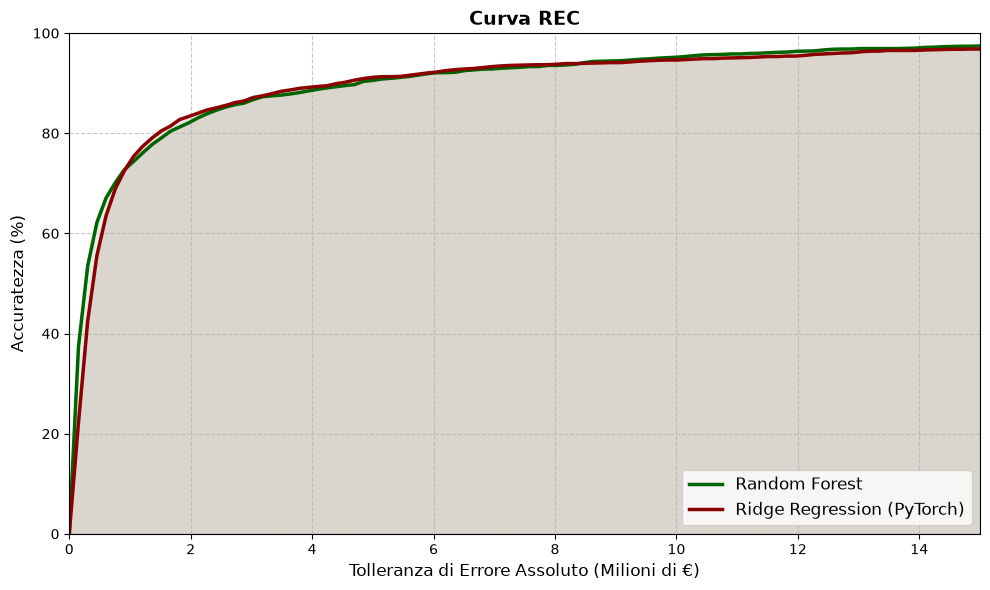

In [ ]:
test_preds_rf_milioni = np.expm1(rf_model.predict(X_test_np))
test_preds_linear_milioni = np.expm1(model(X_poly_testing_norm).detach().cpu().numpy().squeeze())

errori_assoluti_rf = np.abs(y_test_milioni - test_preds_rf_milioni)
errori_assoluti_linear = np.abs(y_test_milioni - test_preds_linear_milioni)

tolleranze = np.linspace(0, 15, 100)
accuratezze_rf = [np.mean(errori_assoluti_rf <= t) * 100 for t in tolleranze]
accuratezze_linear = [np.mean(errori_assoluti_linear <= t) * 100 for t in tolleranze]

plt.figure(figsize=(10, 6))

plt.plot(tolleranze, accuratezze_rf, color='darkgreen', linewidth=2.5, label='Random Forest')
plt.fill_between(tolleranze, accuratezze_rf, color='darkgreen', alpha=0.1)

plt.plot(tolleranze, accuratezze_linear, color='darkred', linewidth=2.5, linestyle='-', label='Ridge Regression')
plt.fill_between(tolleranze, accuratezze_linear, color='darkred', alpha=0.1)

plt.title("Curva REC", fontsize=14, weight='bold')
plt.xlabel("Tolleranza di Errore Assoluto (Milioni di €)", fontsize=12)
plt.ylabel("Accuratezza (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 15)
plt.ylim(0, 100)
plt.legend(loc='lower right', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Analisi dei risultati

In [ ]:
# Colonne categoriche
colonne_categoriche_idx = []
for i in range(X_test_np.shape[1]):
    colonna = X_test_np[:, i]
    valori_unici = np.unique(np.round(colonna, 5))
    if len(valori_unici) == 2:
        colonne_categoriche_idx.append(i)

nomi_categorie = [
    "Dati Presenze",
    "Difensore",
    "Portiere",
    "Centrocampista",
    "Ruolo Mancante",
    "Ligue 1",
    "Premier League",
    "Serie A",
    "Bundesliga"
]

# Predizioni
preds_test_rf = rf_model.predict(X_test_np)
preds_test_rf_milioni = np.expm1(preds_test_rf)
y_test_milioni = np.expm1(Y_test_np)

print("--- Analisi degli Errori per Categoria ---\n")

# Stampa delle metriche
for idx_relativo, col_idx in enumerate(colonne_categoriche_idx):
    colonna = X_test_np[:, col_idx]
    
    valore_vero = np.max(colonna)
    maschera = (colonna >= valore_vero - 1e-5)
    
    y_true_cat = y_test_milioni[maschera]
    y_pred_cat = preds_test_rf_milioni[maschera]
    
    if len(y_true_cat) > 1:
        nome_display = nomi_categorie[idx_relativo]
            
        etichetta = f"{nome_display.upper()} (Campione: {len(y_true_cat)})"
        stampa_metriche(etichetta, y_true_cat, y_pred_cat)
        print("-" * 55)

--- Analisi degli Errori per Categoria ---

Performance in DATI PRESENZE (Campione: 1627):
	MSE: 43.8668 | RMSE: 6.6232 | MAE: 2.3949 | R^2: 0.6727
-------------------------------------------------------
Performance in DIFENSORE (Campione: 712):
	MSE: 29.2214 | RMSE: 5.4057 | MAE: 1.9379 | R^2: 0.6047
-------------------------------------------------------
Performance in PORTIERE (Campione: 272):
	MSE: 4.0866 | RMSE: 2.0215 | MAE: 0.6100 | R^2: 0.7668
-------------------------------------------------------
Performance in CENTROCAMPISTA (Campione: 592):
	MSE: 50.8992 | RMSE: 7.1344 | MAE: 2.2531 | R^2: 0.6209
-------------------------------------------------------
Performance in RUOLO MANCANTE (Campione: 4):
	MSE: 0.0789 | RMSE: 0.2809 | MAE: 0.2210 | R^2: -19.4039
-------------------------------------------------------
Performance in LIGUE 1 (Campione: 391):
	MSE: 23.6000 | RMSE: 4.8580 | MAE: 1.3819 | R^2: 0.4967
-------------------------------------------------------
Performance in P

In [ ]:
# Ricostruzione delle maschere delle categorie nascoste
maschere = {}
for idx_relativo, col_idx in enumerate(colonne_categoriche_idx):
    colonna = X_test_np[:, col_idx]
    valore_vero = np.max(colonna)
    maschere[idx_relativo] = (colonna >= valore_vero - 1e-5)

# Attaccanti
maschera_attaccanti = ~(maschere[1] | maschere[2] | maschere[3] | maschere[4])

y_true_att = y_test_milioni[maschera_attaccanti]
y_pred_att = preds_test_rf_milioni[maschera_attaccanti]

if len(y_true_att) > 1:
    stampa_metriche(f"ATTACCANTE (Campione: {len(y_true_att)})", y_true_att, y_pred_att)
print("-" * 55)

# Liga 
maschera_liga = ~(maschere[5] | maschere[6] | maschere[7] | maschere[8])

y_true_liga = y_test_milioni[maschera_liga]
y_pred_liga = preds_test_rf_milioni[maschera_liga]

if len(y_true_liga) > 1:
    stampa_metriche(f"LA LIGA (Campione: {len(y_true_liga)})", y_true_liga, y_pred_liga)
print("-" * 55)

Performance in ATTACCANTE (Campione: 559):
	MSE: 35.0835 | RMSE: 5.9231 | MAE: 2.0477 | R^2: 0.7734
-------------------------------------------------------
Performance in LA LIGA (Campione: 414):
	MSE: 33.1229 | RMSE: 5.7553 | MAE: 1.6798 | R^2: 0.5887
-------------------------------------------------------


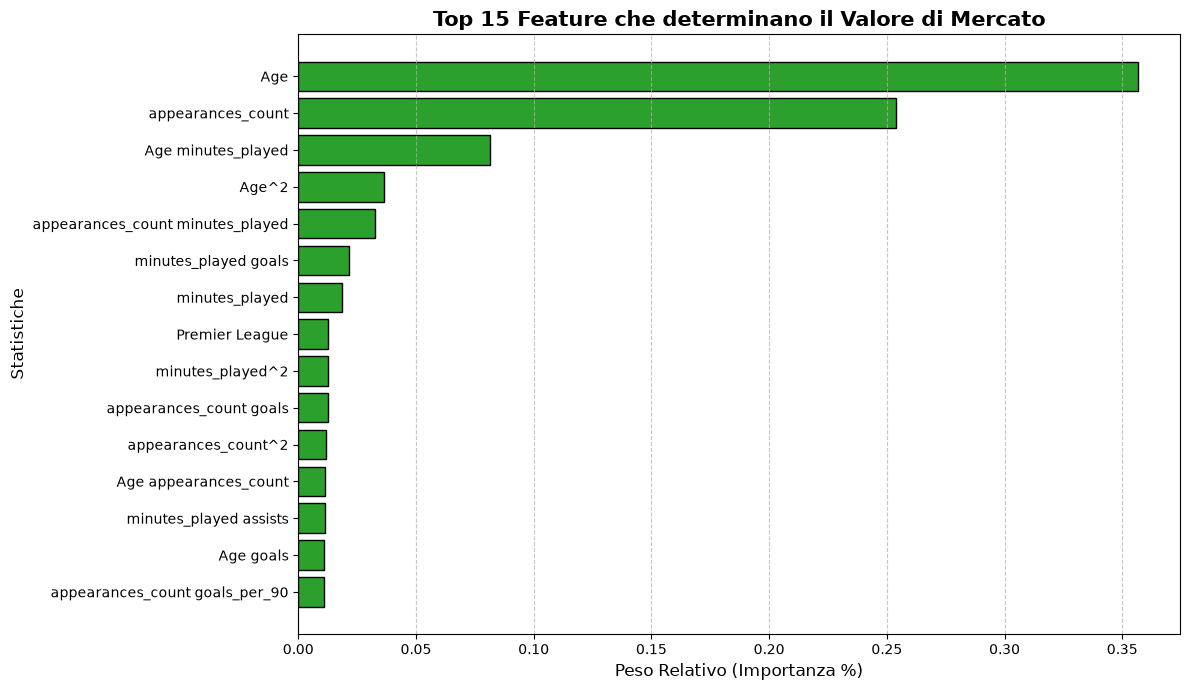

--- Classifica delle Features ---
                                Age : 35.67%
                  appearances_count : 25.40%
                 Age minutes_played :  8.13%
                              Age^2 :  3.66%
   appearances_count minutes_played :  3.26%
               minutes_played goals :  2.17%
                     minutes_played :  1.85%
                     Premier League :  1.28%
                   minutes_played^2 :  1.28%
            appearances_count goals :  1.27%
                appearances_count^2 :  1.17%
              Age appearances_count :  1.13%
             minutes_played assists :  1.12%
                          Age goals :  1.10%
     appearances_count goals_per_90 :  1.08%


In [ ]:
# Features numeriche
nomi_numerici = [
    'Age', 'appearances_count', 'minutes_played', 
    'goals', 'assists', 'goals_per_90', 'assists_per_90'
]

# Features categoriche
nomi_categorici = [
    "Dati Presenze", "Difensore", "Portiere", "Centrocampista", 
    "Ruolo Mancante", "Ligue 1", "Premier League", "Serie A", "Bundesliga"
]

# Generazione dei nomi delle feature polinomiali 
poly_dummy = PolynomialFeatures(degree=2, include_bias=False)
poly_dummy.fit(np.zeros((1, len(nomi_numerici))))
nomi_poly = poly_dummy.get_feature_names_out(nomi_numerici)

# Unione delle liste dei nomi
tutti_i_nomi = list(nomi_poly) + nomi_categorici

# Importanza delle singole Features
importances = rf_model.feature_importances_
df_importanza = pd.DataFrame({
    'Feature': tutti_i_nomi,
    'Importanza': importances
})

# Ordinamento nel grafico
df_grafico = df_importanza.sort_values(by='Importanza', ascending=True).tail(15)

# Grafico
plt.figure(figsize=(12, 7)) # Leggermente più largo per far leggere bene i nomi
plt.barh(df_grafico['Feature'], df_grafico['Importanza'], color='#2ca02c', edgecolor='black')

plt.title("Top 15 Feature che determinano il Valore di Mercato", fontsize=15, weight='bold')
plt.xlabel("Peso Relativo (Importanza %)", fontsize=12)
plt.ylabel("Statistiche", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Stampa in console
print("--- Classifica delle Features ---")
df_stampa = df_importanza.sort_values(by='Importanza', ascending=False).head(15)
for idx, row in df_stampa.iterrows():
    print(f"{row['Feature']:>35} : {row['Importanza']*100:>5.2f}%")

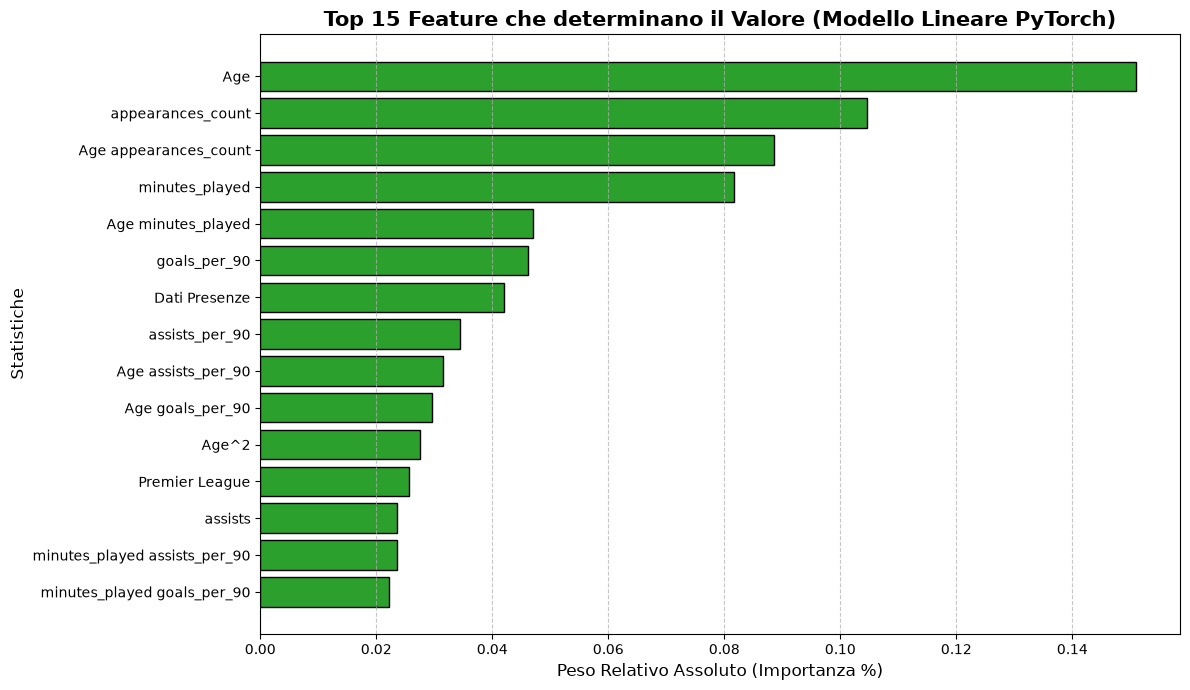

--- CLASSIFICA ASSOLUTA MODELLO LINEARE (IMPATTO PERCENTUALE) ---
                                Age : 15.10%
                  appearances_count : 10.45%
              Age appearances_count :  8.85%
                     minutes_played :  8.16%
                 Age minutes_played :  4.71%
                       goals_per_90 :  4.62%
                      Dati Presenze :  4.21%
                     assists_per_90 :  3.45%
                 Age assists_per_90 :  3.15%
                   Age goals_per_90 :  2.96%
                              Age^2 :  2.75%
                     Premier League :  2.56%
                            assists :  2.36%
      minutes_played assists_per_90 :  2.35%
        minutes_played goals_per_90 :  2.22%


In [ ]:
# Ripeto per il modello lineare
coefficienti = list(model.parameters())[0].detach().cpu().numpy().flatten()

pesi_assoluti = np.abs(coefficienti)
importanza_relativa = pesi_assoluti / np.sum(pesi_assoluti) # Normalizziamo in modo che la somma sia 1 (100%)

df_importanza = pd.DataFrame({
    'Feature': tutti_i_nomi,
    'Importanza': importanza_relativa,
})

df_grafico = df_importanza.sort_values(by='Importanza', ascending=True).tail(15)

# Grafico
plt.figure(figsize=(12, 7))
plt.barh(df_grafico['Feature'], df_grafico['Importanza'], color='#2ca02c', edgecolor='black')

plt.title("Top 15 Feature che determinano il Valore (Modello Lineare PyTorch)", fontsize=15, weight='bold')
plt.xlabel("Peso Relativo Assoluto (Importanza %)", fontsize=12)
plt.ylabel("Statistiche", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Stampa
print("--- CLASSIFICA ASSOLUTA MODELLO LINEARE (IMPATTO PERCENTUALE) ---")
df_stampa = df_importanza.sort_values(by='Importanza', ascending=False).head(15)
for idx, row in df_stampa.iterrows():
    print(f"{row['Feature']:>35} : {row['Importanza']*100:>5.2f}%")